In [5]:
import pymysql
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("All libraries imported successfully!")

All libraries imported successfully!


In [32]:
connection = pymysql.connect(
    host     = 'localhost',
    user     = 'root',
    password = 'H2071',
    database = 'crime_db'
)

print("Connected to crime_db successfully!")

Connected to crime_db successfully!


In [33]:
cursor = connection.cursor()

cursor.execute("SELECT COUNT(*) FROM crime_data;")
total = cursor.fetchone()[0]
print(f"Total records: {total}")

cursor.close()

Total records: 499


In [34]:
df = pd.read_sql("SELECT * FROM crime_data;", connection)

print(f"Shape: {df.shape}")
df.head()

Shape: (499, 13)


C:\Users\HARISH\AppData\Local\Temp\ipykernel_15608\4091109663.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM crime_data;", connection)


,DR_NO,Date_Rptd,DATE_OCC,AREA_NAME,Crm_Cd,Crm_Cd_Desc,Vict_Age,Vict_Sex,Premis_Desc,Status,Location,LAT,LON
0,10304468,01-08-2020,01-08-2020,Southwest,624,BATTERY - SIMPLE ASSAULT,36,F,SINGLE FAMILY DWELLING,AO,1100 W 39TH PL,34.01,-118.30
1,190101086,01-02-2020,01-01-2020,Central,624,BATTERY - SIMPLE ASSAULT,25,M,SIDEWALK,IC,700 S HILL ST,34.05,-118.25
2,191501505,01-01-2020,01-01-2020,N Hollywood,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),76,F,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",IC,5400 CORTEEN PL,34.17,-118.40
3,191921269,01-01-2020,01-01-2020,Mission,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",31,X,BEAUTY SUPPLY STORE,IC,14400 TITUS ST,34.22,-118.45
4,200100502,01-02-2020,01-02-2020,Central,442,SHOPLIFTING - PETTY THEFT ($950 & UNDER),23,M,DEPARTMENT STORE,IC,700 S FIGUEROA ST,34.05,-118.26


In [35]:
df.columns = [
    'dr_no', 'date_reported', 'date_occured', 'area_name',
    'crime_code', 'crime_description', 'victim_age',
    'victim_sex', 'premises_description', 'status',
    'location', 'latitude', 'longitude'
]

print(df.columns.tolist())

['dr_no', 'date_reported', 'date_occured', 'area_name', 'crime_code', 'crime_description', 'victim_age', 'victim_sex', 'premises_description', 'status', 'location', 'latitude', 'longitude']


In [36]:
# Basic info
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   dr_no                 499 non-null    int64  
 1   date_reported         499 non-null    str    
 2   date_occured          499 non-null    str    
 3   area_name             499 non-null    str    
 4   crime_code            499 non-null    int64  
 5   crime_description     499 non-null    str    
 6   victim_age            499 non-null    int64  
 7   victim_sex            499 non-null    str    
 8   premises_description  499 non-null    str    
 9   status                499 non-null    str    
 10  location              499 non-null    str    
 11  latitude              499 non-null    float64
 12  longitude             499 non-null    float64
dtypes: float64(2), int64(3), str(8)
memory usage: 94.1 KB
None


In [37]:
# Summary Stats
df.describe()

,dr_no,crime_code,victim_age,latitude,longitude
count,4.990000e+02,499.000000,499.000000,499.000000,499.000000
mean,1.999930e+08,504.178357,32.142285,34.047335,-118.261283
std,8.742243e+06,198.381863,20.202136,0.053840,0.041560
min,1.030447e+07,210.000000,0.000000,33.710000,-118.560000
25%,2.001044e+08,330.000000,23.000000,34.040000,-118.260000
50%,2.001048e+08,442.000000,31.000000,34.050000,-118.250000
75%,2.001064e+08,624.000000,46.500000,34.050000,-118.240000
max,2.220130e+08,956.000000,78.000000,34.280000,-118.190000


In [38]:
# Missing Values
print(df.isnull().sum())

dr_no                   0
date_reported           0
date_occured            0
area_name               0
crime_code              0
crime_description       0
victim_age              0
victim_sex              0
premises_description    0
status                  0
location                0
latitude                0
longitude               0
dtype: int64


In [39]:
# Unique value counts
print(f"Total Records       : {len(df)}")
print(f"Unique Areas        : {df['area_name'].nunique()}")
print(f"Unique Locations    : {df['location'].nunique()}")
print(f"Unique Crime Codes  : {df['crime_code'].nunique()}")
print(f"Unique Status Types : {df['status'].nunique()}")

Total Records       : 499
Unique Areas        : 19
Unique Locations    : 365
Unique Crime Codes  : 42
Unique Status Types : 4


In [40]:
# Distinct crime codes and descriptions
distinct_crimes = df[['crime_code', 'crime_description']].drop_duplicates().sort_values('crime_code')
print(f"Total distinct crime types: {len(distinct_crimes)}")
distinct_crimes.reset_index(drop=True)

Total distinct crime types: 42


,crime_code,crime_description
0,210,ROBBERY
1,220,ATTEMPTED ROBBERY
2,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT"
3,310,BURGLARY
4,320,"BURGLARY, ATTEMPTED"
5,330,BURGLARY FROM VEHICLE
6,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI..."
7,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER)
8,350,"THEFT, PERSON"
9,351,PURSE SNATCHING


In [41]:
#  Converting date and extracting month
df['date_occured'] = pd.to_datetime(df['date_occured'], errors='coerce')
df['month'] = df['date_occured'].dt.to_period('M')

monthly_crimes = df.groupby('month').size().sort_index()
print(monthly_crimes)

month
2020-01    314
2020-02    130
2020-03      4
2020-04      5
2020-05      5
2020-06      6
2020-07      3
2020-08      3
2020-09      5
2020-10      4
2020-11      8
2020-12     12
Freq: M, dtype: int64


In [42]:
# Print peak and lowest months
print(f"Highest crime month : {monthly_crimes.idxmax()} ({monthly_crimes.max()} crimes)")
print(f"Lowest crime month  : {monthly_crimes.idxmin()} ({monthly_crimes.min()} crimes)")

Highest crime month : 2020-01 (314 crimes)
Lowest crime month  : 2020-07 (3 crimes)


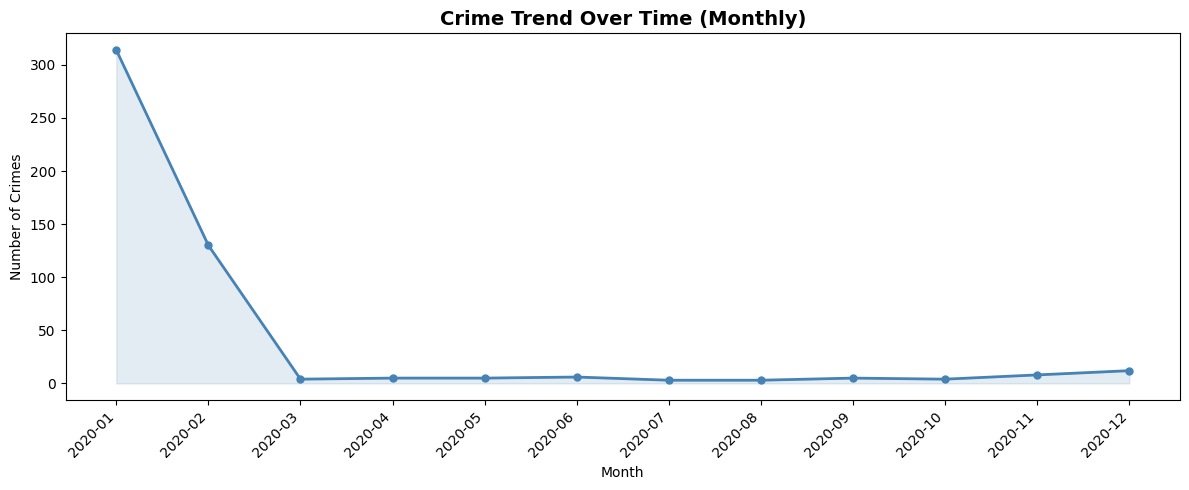

In [43]:
# Plotting Crime trend over time
plt.figure(figsize=(12, 5))
plt.plot(monthly_crimes.index.astype(str), monthly_crimes.values,
         marker='o', linewidth=2, color='steelblue', markersize=5)
plt.fill_between(monthly_crimes.index.astype(str), monthly_crimes.values,
                 alpha=0.15, color='steelblue')
plt.title("Crime Trend Over Time (Monthly)", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [44]:
df_spatial = df[
    (df['latitude'].notna())  & (df['longitude'].notna()) &
    (df['latitude']  != 0)    & (df['longitude']  != 0)
].copy()

print(f"Records with valid coordinates: {len(df_spatial)}")

Records with valid coordinates: 499


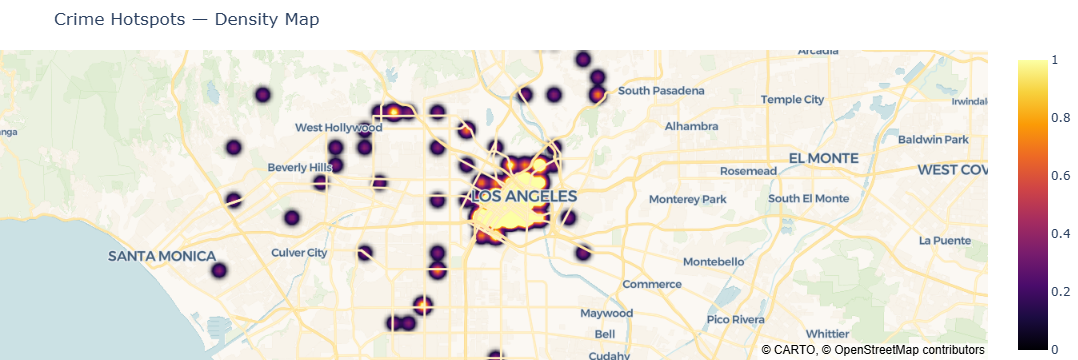

In [45]:
# Interactive crime hotspot map
fig = px.density_map(
    df_spatial,
    lat='latitude',
    lon='longitude',
    radius=12,
    center=dict(
        lat=df_spatial['latitude'].mean(),
        lon=df_spatial['longitude'].mean()
    ),
    zoom=10,
    title='Crime Hotspots — Density Map',
    color_continuous_scale='Inferno'
)
fig.update_layout(margin=dict(t=50, b=0, l=0, r=0))
fig.show()

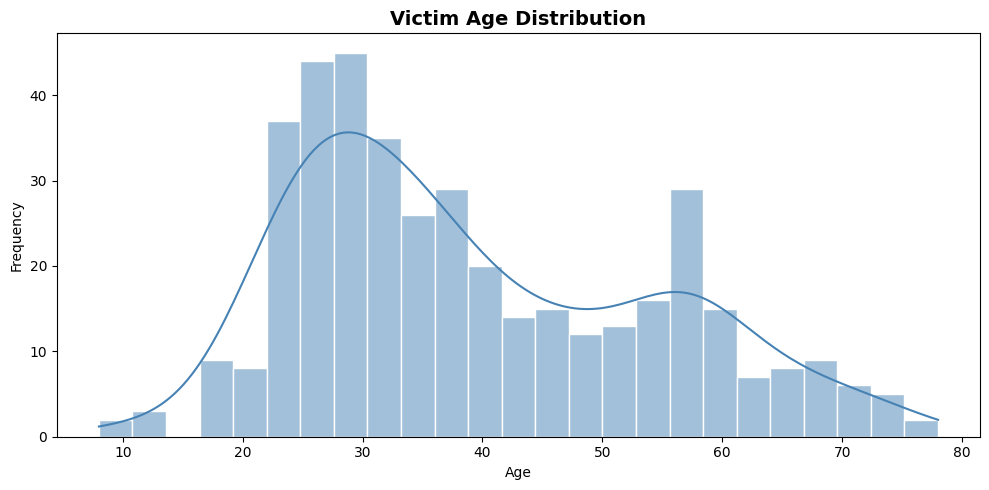

Average victim age : 39.2 years
Median victim age  : 35 years


In [46]:
# Victim age distribution
df['victim_age_clean'] = df['victim_age'].replace(0, pd.NA)

plt.figure(figsize=(10, 5))
sns.histplot(df['victim_age_clean'].dropna(), bins=25, kde=True,
             color='steelblue', edgecolor='white')
plt.title("Victim Age Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"Average victim age : {df['victim_age_clean'].mean():.1f} years")
print(f"Median victim age  : {df['victim_age_clean'].median():.0f} years")

gender_label
Male             278
Female           155
Unknown/Other     66
Name: count, dtype: int64


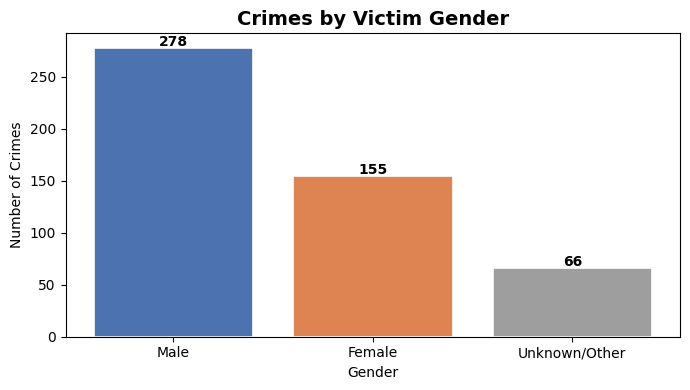

In [47]:
# victim gender distribution
gender_map = {'M': 'Male', 'F': 'Female', 'X': 'Unknown/Other'}
df['gender_label'] = df['victim_sex'].map(gender_map).fillna('Unknown/Other')

gender_counts = df['gender_label'].value_counts()
print(gender_counts)

plt.figure(figsize=(7, 4))
colors = ['#4C72B0', '#DD8452', '#9e9e9e']
bars = plt.bar(gender_counts.index, gender_counts.values, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, gender_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha='center', fontweight='bold')
plt.title("Crimes by Victim Gender", fontsize=14, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Number of Crimes")
plt.tight_layout()
plt.show()

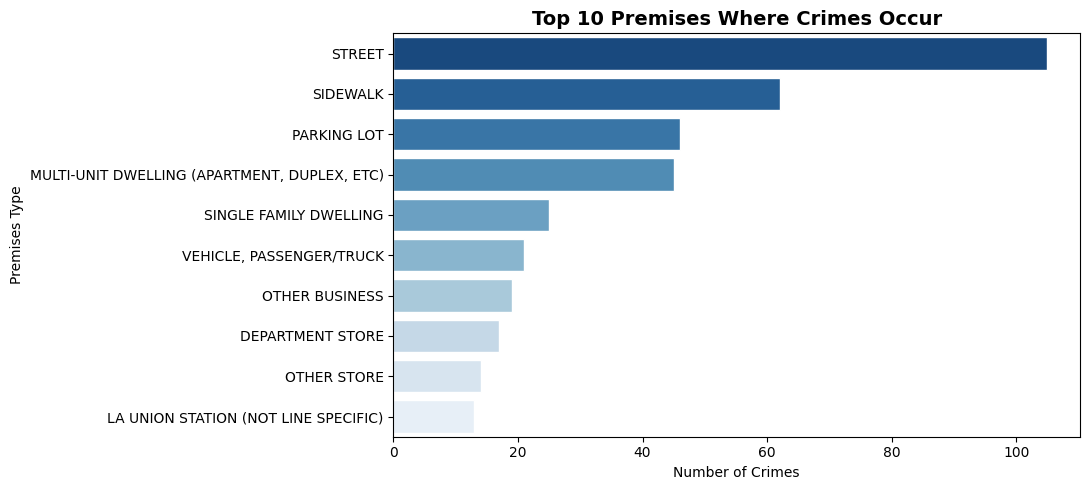

premises_description
STREET                                          105
SIDEWALK                                         62
PARKING LOT                                      46
MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)     45
SINGLE FAMILY DWELLING                           25
VEHICLE, PASSENGER/TRUCK                         21
OTHER BUSINESS                                   19
DEPARTMENT STORE                                 17
OTHER STORE                                      14
LA UNION STATION (NOT LINE SPECIFIC)             13
Name: count, dtype: int64


In [54]:
# Top 10 Premises
top_premises = df['premises_description'].value_counts().head(10)

plt.figure(figsize=(11, 5))
sns.barplot(x=top_premises.values, y=top_premises.index,
            hue=top_premises.index, palette='Blues_r', edgecolor='white', legend=False)
plt.title("Top 10 Premises Where Crimes Occur", fontsize=14, fontweight='bold')
plt.xlabel("Number of Crimes")
plt.ylabel("Premises Type")
plt.tight_layout()
plt.show()

print(top_premises)

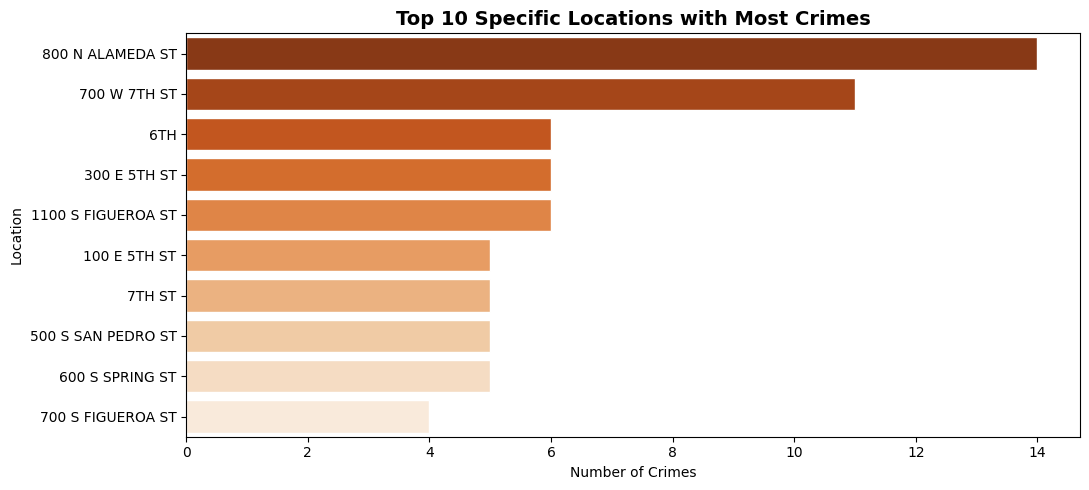

location
800 N ALAMEDA ST      14
700 W 7TH ST          11
6TH                    6
300 E 5TH ST           6
1100 S FIGUEROA ST     6
100 E 5TH ST           5
7TH ST                 5
500 S SAN PEDRO ST     5
600 S SPRING ST        5
700 S FIGUEROA ST      4
Name: count, dtype: int64


In [53]:
# Top 10 Crime locations
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(11, 5))
sns.barplot(x=top_locations.values, y=top_locations.index,
            hue=top_locations.index, palette='Oranges_r', edgecolor='white', legend=False)
plt.title("Top 10 Specific Locations with Most Crimes", fontsize=14, fontweight='bold')
plt.xlabel("Number of Crimes")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

print(top_locations)

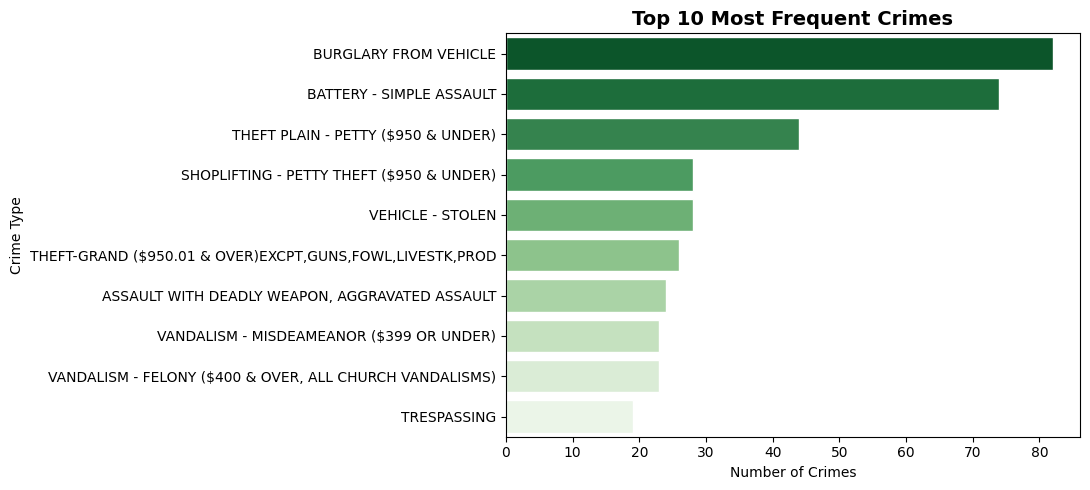

crime_description
BURGLARY FROM VEHICLE                                       82
BATTERY - SIMPLE ASSAULT                                    74
THEFT PLAIN - PETTY ($950 & UNDER)                          44
SHOPLIFTING - PETTY THEFT ($950 & UNDER)                    28
VEHICLE - STOLEN                                            28
THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD    26
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              24
VANDALISM - MISDEAMEANOR ($399 OR UNDER)                    23
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)     23
TRESPASSING                                                 19
Name: count, dtype: int64


In [52]:
# Top 10 Most frequent crimes
top_crimes = df['crime_description'].value_counts().head(10)

plt.figure(figsize=(11, 5))
sns.barplot(x=top_crimes.values, y=top_crimes.index,
            hue=top_crimes.index, palette='Greens_r', edgecolor='white', legend=False)
plt.title("Top 10 Most Frequent Crimes", fontsize=14, fontweight='bold')
plt.xlabel("Number of Crimes")
plt.ylabel("Crime Type")
plt.tight_layout()
plt.show()

print(top_crimes)

status_label
Investigation Continued    447
Adult Arrest                27
Adult Other                 24
Juvenile Other               1
Name: count, dtype: int64


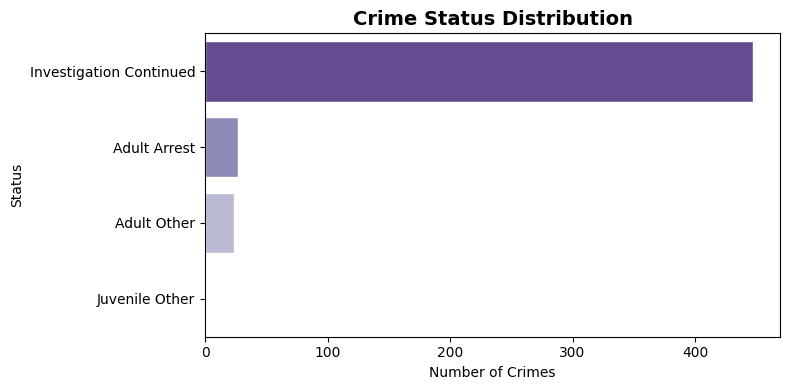

In [51]:
# Crime status distribution
status_map = {
    'IC': 'Investigation Continued',
    'AA': 'Adult Arrest',
    'AO': 'Adult Other',
    'JO': 'Juvenile Other',
    'JA': 'Juvenile Arrest'
}
df['status_label'] = df['status'].map(status_map).fillna(df['status'])

status_counts = df['status_label'].value_counts()
print(status_counts)

plt.figure(figsize=(8, 4))
sns.barplot(x=status_counts.values, y=status_counts.index,
            hue=status_counts.index, palette='Purples_r', edgecolor='white', legend=False)
plt.title("Crime Status Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Number of Crimes")
plt.ylabel("Status")
plt.tight_layout()
plt.show()

In [ ]:
connection.close()
print("Database connection closed.")